Expected community sizes: [100.  30.  70.]
Observed community sizes: [107  28  65]


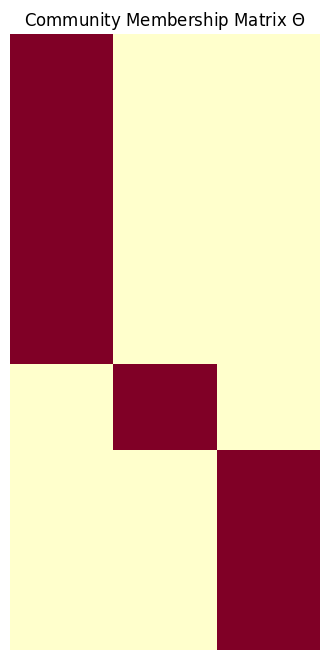

P[1,3] = 0.9
P[197,199] = 0.25
P[192,4] = 0.25


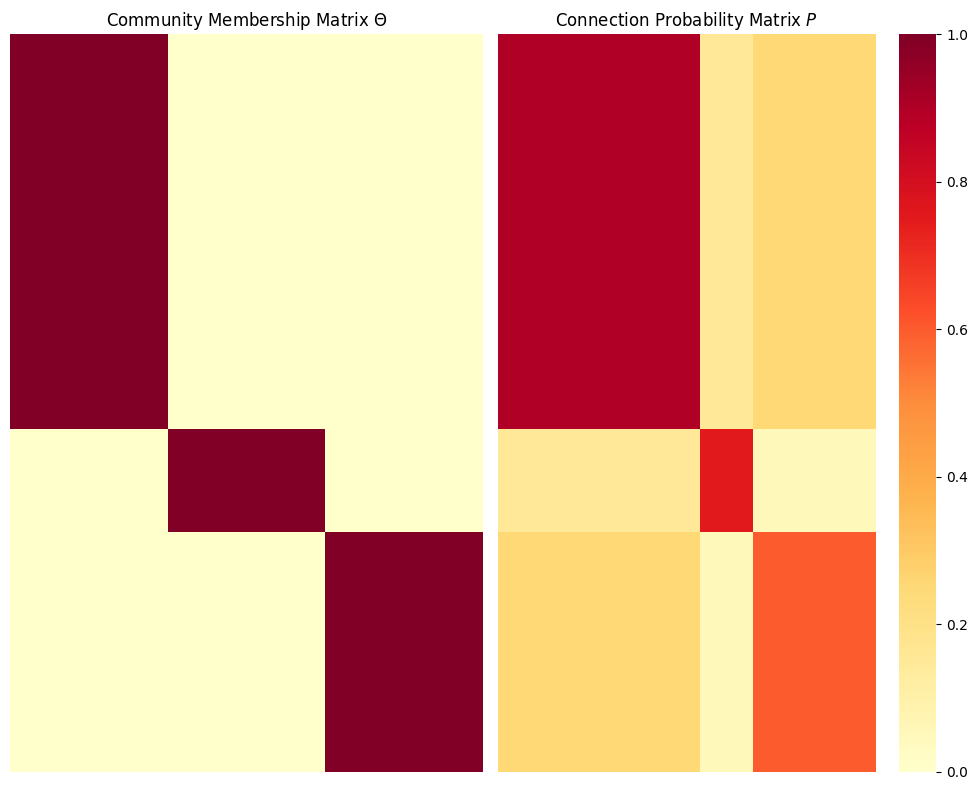

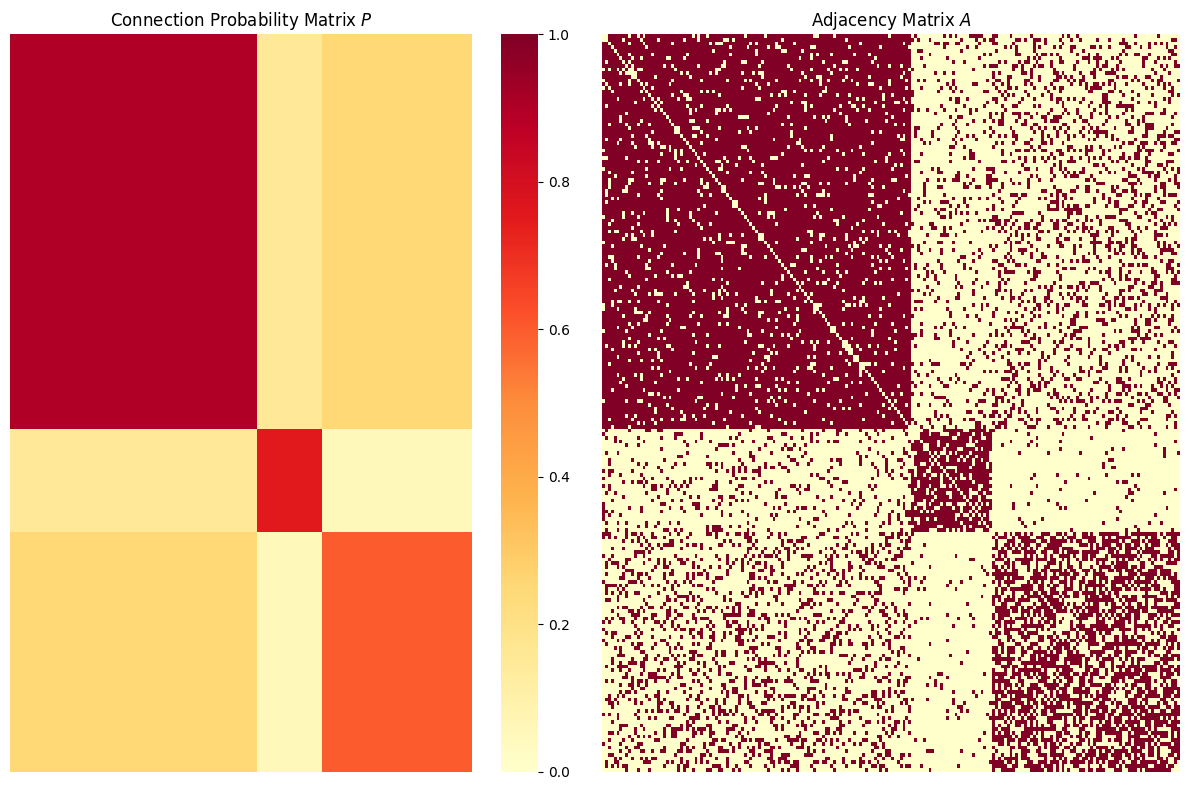

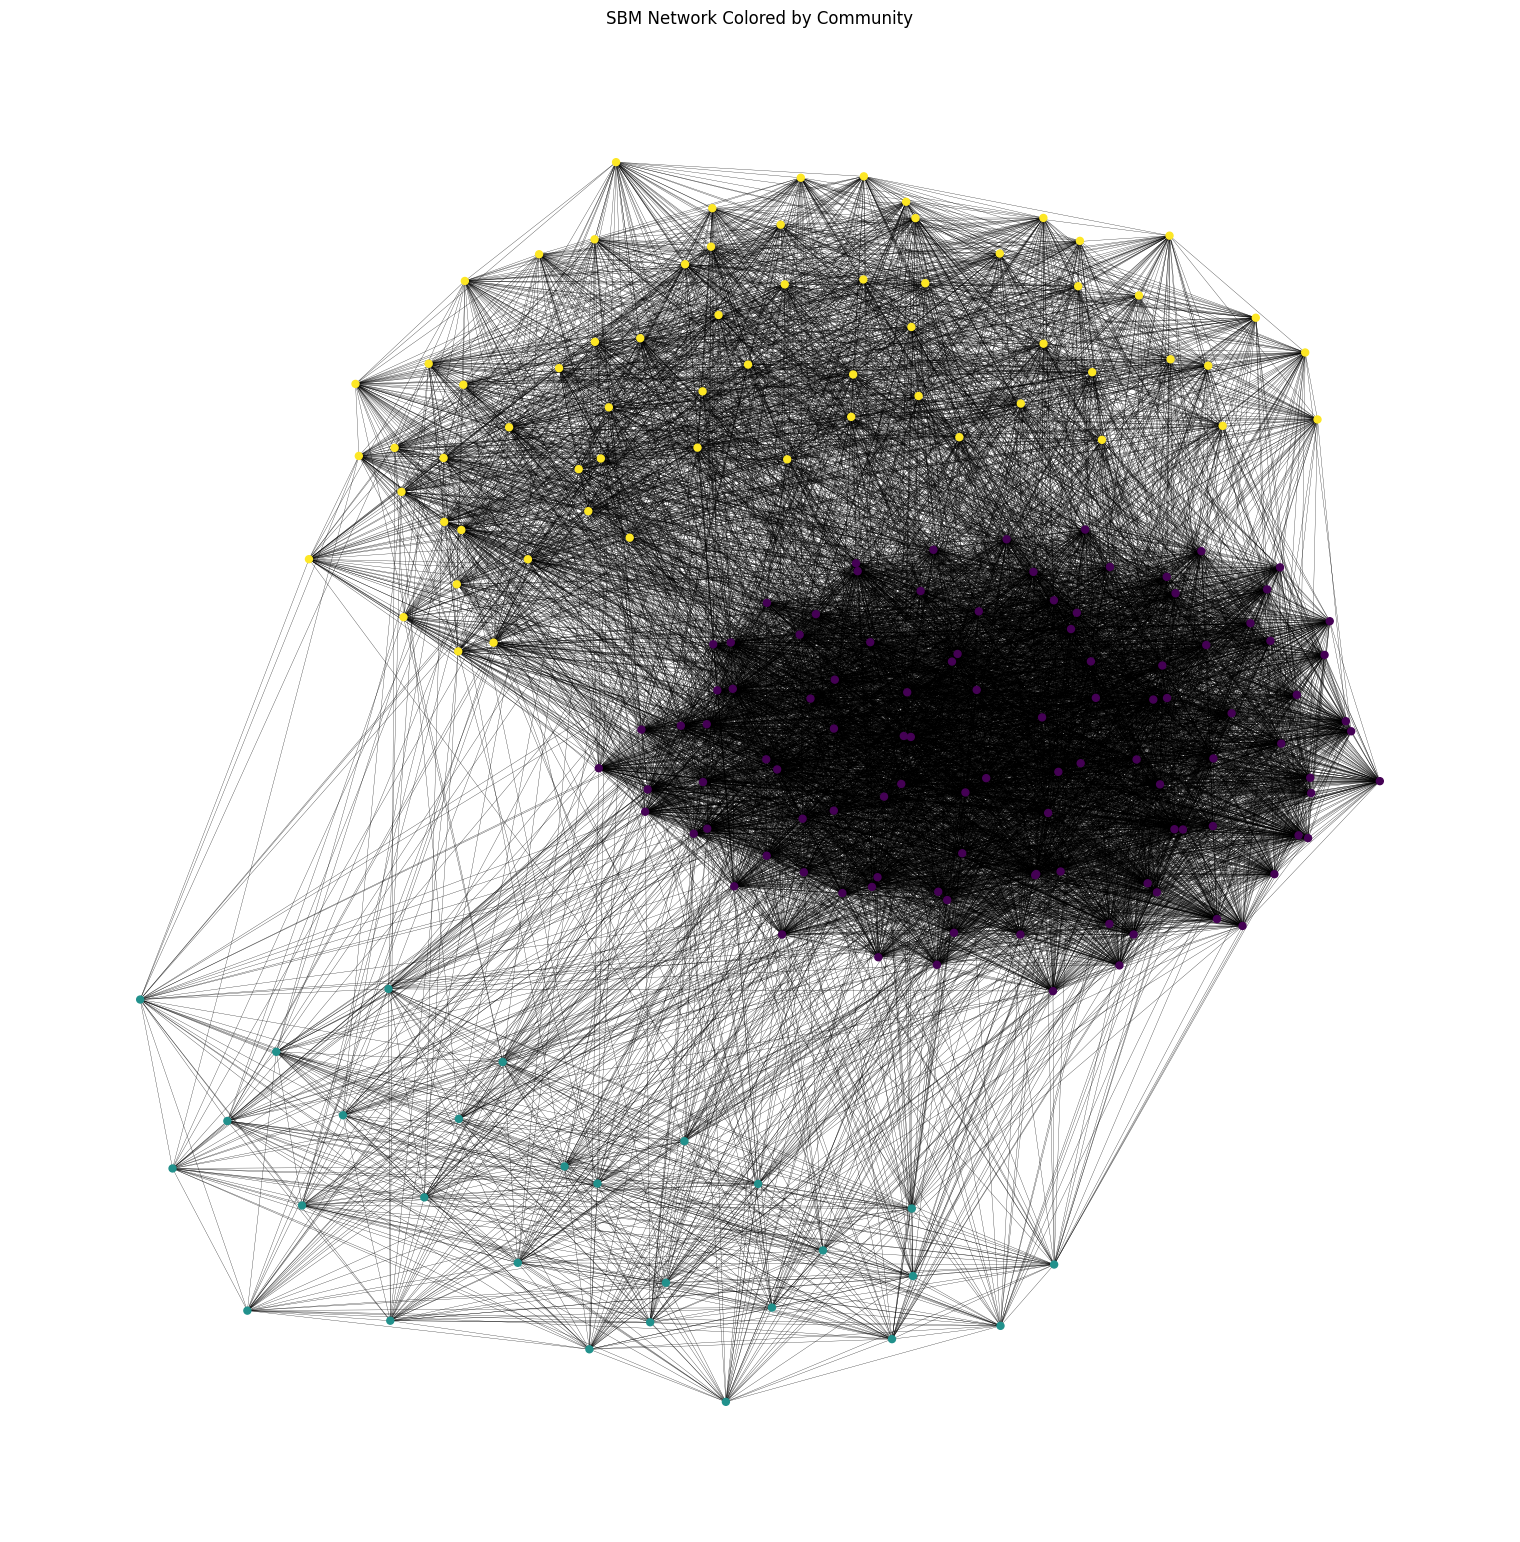

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

#A)

#Parameters:
n = 200
pi = np.array([0.5, 0.15, 0.35])
B = np.array([[0.9,  0.15, 0.25],
              [0.15, 0.75, 0.05],
              [0.25, 0.05, 0.6]])

rho = 1

#Theta:
Theta = np.random.multinomial(1, pi, size=n)

#Expected number of nodes in each community:
expected = n * pi

#Observed number of nodes in each community:
observed = np.sum(Theta, axis=0)

print("Expected community sizes:", expected)
print("Observed community sizes:", observed)

#Find the community label for each node:
community = np.argmax(Theta, axis=1)

#Sort nodes by community for visualization:
order = np.argsort(community)
Theta_sorted = Theta[order, :]

#Plot:
plt.figure(figsize=(4, 8))

sns.heatmap(Theta_sorted,
            cmap="YlOrRd",
            cbar=False,
            vmin=0,
            vmax=1)

plt.title("Community Membership Matrix $\\Theta$")
plt.xticks([])
plt.yticks([])

plt.show()

#B)

#Create the connection probability matrix P:
P = rho * Theta @ B @ Theta.T

print("P[1,3] =", P[0,2])
print("P[197,199] =", P[196,198])
print("P[192,4] =", P[191,3])

#Sort P:
P_sorted = P[np.ix_(order, order)]

#Plot Theta and P beside eachother:
fig, ax = plt.subplots(1, 2, figsize=(10, 8))

#Theta heatmap:
sns.heatmap(Theta_sorted,
            cmap="YlOrRd",
            cbar=False,
            vmin=0,
            vmax=1,
            ax=ax[0])

ax[0].set_title("Community Membership Matrix $\\Theta$")
ax[0].set_xticks([])
ax[0].set_yticks([])

#P heatmap:
sns.heatmap(P_sorted,
            cmap="YlOrRd",
            vmin=0,
            vmax=1,
            ax=ax[1])

ax[1].set_title("Connection Probability Matrix $P$")
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

#C)

#Generate random instance of Adjacency Matrix A:
R = np.random.uniform(size=(n, n))

#Make the random matrix symmetric (since undirected i.e., Aij = Aji):
R1 = np.triu(R) + np.triu(R, 1).T

#Generate A:
A = 1 * (R1 < P)

#Remove self-connections (i.e., Aii = 0 for all i):
A = A - np.diag(np.diag(A))

#Sort A:
A_sorted = A[np.ix_(order, order)]

#Plot P and A beside eachother:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

#Connection probability matrix P:
sns.heatmap(P_sorted,
            cmap="YlOrRd",
            vmin=0,
            vmax=1,
            ax=ax[0])

ax[0].set_title("Connection Probability Matrix $P$")
ax[0].set_xticks([])
ax[0].set_yticks([])

#Adjacency matrix A:
sns.heatmap(A_sorted,
            cmap="YlOrRd",
            cbar=False,
            vmin=0,
            vmax=1,
            ax=ax[1])

ax[1].set_title("Adjacency Matrix $A$")
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

#D)

#Create graph from adjacency matrix:
G = nx.from_numpy_array(A)

#Community labels for every node:
labels = np.argmax(Theta, axis=1)

#Node coloring based on community:
node_colors = labels

#Plot network:
plt.figure(figsize=(15, 15))

nx.draw(G,
    node_color=node_colors,
    cmap="viridis",
    node_size=25,
    width=0.2,
    with_labels=False)

plt.title("SBM Network Colored by Community")
plt.show()

#The network shows stronger connectivity within communities than across
#communities. Among the three communities, community 1 has the highest
#within-community connection density with probability 0.90, followed by
#community 2 with 0.75, and community 3 with 0.60. Across communities,
#communities 1 and 3 have the highest connection density at 0.25,
#while communities 2 and 3 have the lowest at 0.05.
#Therefore, the overall highest connection density is within community 1,
#and the lowest is between communities 2 and 3. This is reflected in the
#SBM Network plot.